In [23]:
import pandas as pd
import lightgbm as lgb
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from sentence_transformers import SentenceTransformer
import os
from sklearn.decomposition import PCA

os.environ['USE_TF'] = 'NO'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # Désactive les logs d'erreurs TF

nlp_model = SentenceTransformer('all-MiniLM-L6-v2')

class FinfrogTrainer:
    def __init__(self, data_path):
        features = ['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
                    'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership',
                    'annual_inc', 'verification_status','loan_status', 'dti', 'open_acc']
        self.df = pd.read_csv(data_path, usecols=features)
        self.model = None
        self.pca = None # Initialize pca attribute
        self.job_map = None # Initialize job_map attribute

    def preprocess(self):

        ######################
            # On nettoie et on récupère uniquement les titres uniques pour gagner du temps
        trainer.df['emp_title'] = trainer.df['emp_title'].fillna('unknown')
        unique_titles = self.df['emp_title'].astype(str).unique().tolist()

        # 2. Transformer le texte en vecteurs (coordonnées numériques)
        embeddings = nlp_model.encode(unique_titles, show_progress_bar=True)

        # 3. Créer un dictionnaire de correspondance {Titre: Vecteur}
        self.job_map = {title: emb for title, emb in zip(unique_titles, embeddings)} # Store job_map

        # Exemple simple : on crée une feature "Job_Score" (moyenne du vecteur)
        # ou on concatène les 3 premières dimensions
        df_embeddings = self.df['emp_title'].map(self.job_map)

        # Conversion en matrice numpy (N_lignes, 384)
        full_matrix = np.stack(df_embeddings.values).astype(np.float32)

        # 2. Configuration et calcul de la PCA
        self.pca = PCA(n_components=8) # Store pca as an instance attribute
        reduced_matrix = self.pca.fit_transform(full_matrix)

        # 3. Intégration dans le DataFrame
        for i in range(8):
            self.df[f'job_pca_{i}'] = reduced_matrix[:, i]


        ##########################

        features = ['loan_amnt', 'funded_amnt', 'funded_amnt_inv',
                    'dti_loan', 'emp_length', 'home_ownership',
                    'annual_inc', 'verification_status', 'dti', 'open_acc',
                    'job_pca_0','job_pca_1','job_pca_2','job_pca_3',
                    'job_pca_4','job_pca_5','job_pca_6','job_pca_7']

        self.df = self.df[self.df['loan_status'].isin(['Fully Paid', 'Charged Off'])]
        self.df = self.df[self.df['term'].isin([' 36 months', ' 60 months'])]
        self.df['term'] = self.df['term'].apply(lambda x: 36 if x == ' 36 months' else 60)
        self.df['target'] = self.df['loan_status'].apply(lambda x: 1 if x == 'Charged Off' else 0)
        # 1. Gestion de la Target (Toujours nécessaire en premier)
        if 'loan_status' in self.df.columns:
            self.df = self.df[self.df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
            self.df['target'] = self.df['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})
            self.df = self.df.drop(columns=['loan_status'])

        # 2. Traitement spécifique des colonnes connues pour être pénibles
        if 'emp_length' in self.df.columns:
            self.df['emp_length'] = self.df['emp_length'].astype(str).str.replace(r'\+? years?', '', regex=True)
            self.df['emp_length'] = self.df['emp_length'].str.replace('< 1', '0', regex=False)
            self.df['emp_length'] = pd.to_numeric(self.df['emp_length'], errors='coerce').fillna(-1)

        if 'verification_status' in self.df.columns:
            verif_map = {'Not Verified': 0, 'Source Verified': 1, 'Verified': 2}
            self.df['verification_status'] = self.df['verification_status'].map(verif_map).fillna(-1)

        # 3. BOUCLE POUR LES STR (Grades, Verification, etc.)
        # On cible tout ce qui n'est pas un chiffre
        text_cols = self.df.select_dtypes(include=['object', 'category']).columns

        for col in text_cols:
            if col == 'emp_title':
                self.df[col] = self.df[col].astype(str).str.lower().fillna('unknown')
            else:
                # On force le type 'category' pour que LightGBM accepte 'A', 'B', 'C'...
                self.df[col] = self.df[col].astype('category')
                # ASTUCE : On récupère les codes numériques des catégories pour être sûr
                # Cela transforme 'A' en 0, 'B' en 1, etc. tout en gardant l'info
                self.df[col] = self.df[col].cat.codes

        #on crée une variable pour dti_loan (!= de dti)
        trainer.df['dti_loan'] = trainer.df['installment']/(trainer.df['annual_inc']/12)

        # 4. Remplissage des NaNs numériques
        num_cols = self.df.select_dtypes(include=[np.number]).columns
        self.df[num_cols] = self.df[num_cols].fillna(self.df[num_cols].median())


        self.X = self.df[features]
        self.y = self.df['target']

        return train_test_split(self.X, self.y, test_size=0.2, random_state=42)

    def train(self, X_train, y_train):
        # Hyperparamètres de base pour le risque de crédit
        # Exemple de configuration "Expert"
        params = {
            'objective': 'binary',
            'metric': 'auc',
            'learning_rate': 0.02,
            'num_leaves': 127,
            'max_depth': 10,
            'min_data_in_leaf': 100,
            'feature_fraction': 0.8,
            'cat_smooth': 10,
            'scale_pos_weight': 4,
            'verbosity': -1
        }

        # Entraînement avec arrêt automatique


        X_train = np.array(X_train)
        y_train = np.array(y_train)
        train_data = lgb.Dataset(X_train, label=y_train)
        test_data = lgb.Dataset(X_test, label=y_test)
        self.model = lgb.train(params,
                               train_data,
                               valid_sets=[test_data],
                               num_boost_round=10000,
                               callbacks=[lgb.early_stopping(stopping_rounds=100)]
                                )
        print("Entraînement terminé !")
        # Sauvegarde au format texte (très léger et rapide)
        self.model.save_model('scoring_model.txt')
        print("Modèle sauvegardé avec succès !")

# --- Usage ---
trainer = FinfrogTrainer('accepted_2007_to_2018Q4.csv')
X_train, X_test, y_train, y_test = trainer.preprocess()

# On convertit les Series y en DataFrame pour le stockage Parquet
pd.DataFrame(X_train).to_parquet('X_train.parquet')
pd.DataFrame(X_test).to_parquet('X_test.parquet')
pd.DataFrame(y_train).to_parquet('y_train.parquet')
pd.DataFrame(y_test).to_parquet('y_test.parquet')

print("Fichiers de Split sauvegardés dans data/ !")
trainer.train(X_train, y_train)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/tmp/ipython-input-1932241038.py:20: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  self.df = pd.read_csv(data_path, usecols=features)


Batches:   0%|          | 0/16022 [00:00<?, ?it/s]

Fichiers de Split sauvegardés dans data/ !
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2379]	valid_0's auc: 0.670727
Entraînement terminé !
Modèle sauvegardé avec succès !


L'AUC du modèle est de : 0.7117


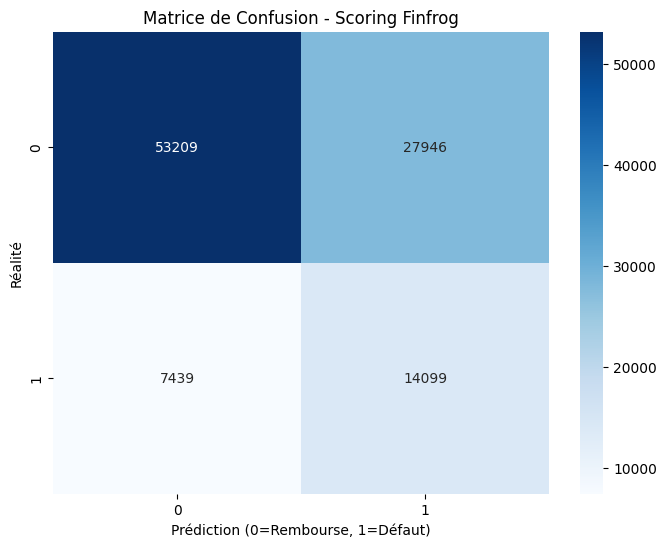

In [11]:
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import lightgbm as lgb
import numpy as np
import pandas as pd

y_pred_proba = trainer.model.predict(X_test)
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"L'AUC du modèle est de : {auc_score:.4f}")

# 2. Matrice de confusion (Seuil par défaut 0.5)
y_pred_binary = [1 if x > 0.5 else 0 for x in y_pred_proba]
cm = confusion_matrix(y_test, y_pred_binary)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prédiction (0=Rembourse, 1=Défaut)')
plt.ylabel('Réalité')
plt.title('Matrice de Confusion - Scoring Finfrog')
plt.show()

In [15]:
len(y_test)

179849

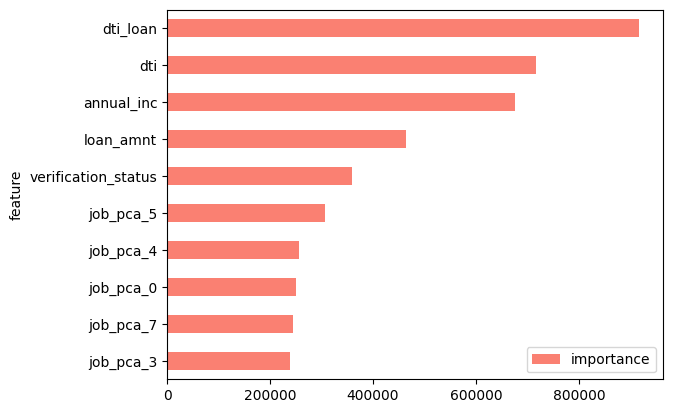

In [14]:
import matplotlib.pyplot as plt

# On récupère les scores d'importance
importance_scores = trainer.model.feature_importance(importance_type='gain')

# On récupère les noms (on force la conversion en liste pour être sûr)
names = list(X_test.columns)

# Création du DataFrame proprement
importance_df = pd.DataFrame({'feature': names, 'importance': importance_scores})
importance_df = importance_df.sort_values('importance', ascending=False)

# Affichage direct via pandas (plus simple)
importance_df.head(10).plot(kind='barh', x='feature', y='importance', color='salmon')
plt.gca().invert_yaxis() # Pour avoir le plus important en haut
plt.show()

In [19]:
trainer.df['dti']

,dti
0,5.91
1,16.06
2,10.78
4,25.37
5,10.20
...,...
1471117,20.19
1471132,9.49
1471137,8.38
1471150,73.29


In [34]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
features = ['loan_amnt', 'funded_amnt', 'funded_amnt_inv',
                    'dti_loan', 'emp_length', 'home_ownership',
                    'annual_inc', 'verification_status', 'dti', 'open_acc',
                    'job_pca_0','job_pca_1','job_pca_2','job_pca_3',
                    'job_pca_4','job_pca_5','job_pca_6','job_pca_7']

# 1. PRÉPARATION DES DONNÉES (On adapte la cible)
def prepare_regression_data(df):
    # The 'features' list defined in this cell already contains the desired columns for X.
    # By directly selecting these features, we ensure 'emp_title' (and other non-feature columns) are excluded.
    X = df[features].copy()
    y = df['int_rate']

    # Store the feature names for consistent prediction later
    # Assuming 'trainer' object is accessible here and can store this attribute
    trainer.regression_feature_names = X.columns.tolist()

    return train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_test, y_train, y_test = prepare_regression_data(trainer.df)

# 2. CONFIGURATION DU MODÈLE DE RÉGRESSION
print("Entraînement du modèle de tarification (Régression)...")

params_reg = {
    'objective': 'regression',
    'metric': 'rmse',      # Root Mean Squared Error
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'feature_fraction': 0.9,
    'verbosity': -1
}

# Création des datasets LightGBM
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# 3. ENTRAÎNEMENT
reg_model = lgb.train(
    params_reg,
    train_data,
    valid_sets=[test_data],
    num_boost_round=1000,
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# 4. ÉVALUATION
y_pred = reg_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n--- RÉSULTATS RÉGRESSION ---")
print(f"Erreur Moyenne (MAE) : {mae:.2f} %") # Ex: 1.50 signifie qu'on se trompe de 1.5% sur le taux
print(f"Score R² : {r2:.4f}") # Plus c'est proche de 1, plus le modèle est précis

Entraînement du modèle de tarification (Régression)...
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's rmse: 3.86346

--- RÉSULTATS RÉGRESSION ---
Erreur Moyenne (MAE) : 2.89 %
Score R² : 0.3448


In [38]:
def simuler_taux(job_title, annual_inc, loan_amnt, funded_amnt, funded_amnt_inv,
                 term, grade, sub_grade, emp_length, installment,
                 dti, open_acc, verification_status, home_ownership,
                 _id=0, _member_id=0):

    # 1. Préparation du dictionnaire de données
    input_data_dict = {
        'id': _id,
        'member_id': _member_id,
        'loan_amnt': loan_amnt,
        'funded_amnt': funded_amnt,
        'funded_amnt_inv': funded_amnt_inv,
        'term': term,
        'grade': grade, # These should be the numerical codes after cat.codes conversion in preprocess
        'sub_grade': sub_grade, # These should be the numerical codes
        'emp_length': emp_length, # These should be the numerical codes
        'home_ownership': home_ownership, # These should be the numerical codes
        'annual_inc': annual_inc,
        'verification_status': verification_status, # These should be the numerical codes
        'dti': dti,
        'open_acc': open_acc,
        'emp_title': job_title.lower().strip(), # Temporary, will be dropped
        'installment': installment # Temporary, used for dti_loan calculation
    }
    input_data = pd.DataFrame([input_data_dict])

    # 2. Calculate dti_loan (matching how it was calculated in preprocess)
    input_data['dti_loan'] = input_data['installment'] / (input_data['annual_inc'] / 12)

    # 3. Application du NLP (Embeddings + PCA)
    # On récupère le vecteur du titre via ton job_map
    # Use trainer.job_map to get the embedding for the specific job title
    # If the job title is new, we need to encode it with nlp_model
    if job_title.lower().strip() in trainer.job_map:
        emb = trainer.job_map[job_title.lower().strip()].reshape(1, -1) # Reshape for single sample
    else:
        emb = nlp_model.encode([job_title.lower().strip()])

    # On applique la PCA (on réutilise l'objet 'pca' entraîné plus haut)
    pca_vectors = trainer.pca.transform(emb)

    for i in range(8):
        input_data[f'job_pca_{i}'] = pca_vectors[0][i]

    # 4. Nettoyage final avant prédiction
    # Drop columns that were not part of the final training features for reg_model
    X_simul = input_data.drop(columns=['emp_title', 'installment'])

    # Ensure column order matches training data X_train.columns
    # This relies on trainer.regression_feature_names being set after reg_model training
    if hasattr(trainer, 'regression_feature_names'):
        X_simul = X_simul[trainer.regression_feature_names]
    else:
        # Fallback if regression_feature_names is not available (e.g., if preprocess not run correctly)
        # This should ideally not happen if execution flow is correct
        print("Warning: trainer.regression_feature_names not found. Prediction may fail due to mismatched columns.")

    # 5. Prédiction
    taux_predit = reg_model.predict(X_simul)[0]

    return round(taux_predit, 2)

# Example call with all required parameters
# Note: grade, sub_grade, emp_length, home_ownership, verification_status should be numerical codes
print(simuler_taux('data scientist',
                   annual_inc=40000,
                   loan_amnt=10000,
                   funded_amnt=10000, # Assuming funded_amnt = loan_amnt for simulation
                   funded_amnt_inv=10000, # Assuming funded_amnt_inv = loan_amnt for simulation
                   term=36, # Example term (36 or 60)
                   grade=0, # Example grade (e.g., 0 for A, 1 for B, etc. as per cat.codes)
                   sub_grade=0, # Example sub_grade
                   emp_length=1, # Example employment length (0 for <1 year, 1 for 1 year, etc.)
                   installment=300, # Example installment, used to calculate dti_loan
                   dti=10,
                   open_acc=3,
                   verification_status=2, # Example verification status (0=Not Verified, 1=Source Verified, 2=Verified)
                   home_ownership=0 # Example home_ownership (e.g., 0 for MORTGAGE, 1 for RENT as per cat.codes)
                  ))

14.69


In [37]:
# Liste de métiers à tester
jobs_to_test = [
    "Software Engineer", "Registered Nurse", "Teacher",
    "Construction Worker", "Police Officer", "Sales Manager",
    "Cashier", "Unemployed", "Doctor", "Truck Driver"
]

def benchmark_jobs(job_list, base_income=40000, base_loan=10000):
    results = []

    print(f"--- Simulation pour un prêt de {base_loan}$ (Revenu: {base_income}$/an) ---")

    for job in job_list:
        # On simule le taux via notre fonction précédente
        # (Assure-toi que 'simuler_taux' est bien définie avec tes objets reg_model et pca)
        # Corrected call to simuler_taux with all required arguments and appropriate default values
        taux = simuler_taux(job_title=job,
                            annual_inc=base_income,
                            loan_amnt=base_loan,
                            funded_amnt=base_loan, # Assuming funded_amnt equals loan_amnt for simulation
                            funded_amnt_inv=base_loan, # Assuming funded_amnt_inv equals loan_amnt for simulation
                            term=36, # Default term to 36 months
                            grade=0, # Default numerical code for grade (e.g., 'A')
                            sub_grade=0, # Default numerical code for sub_grade (e.g., 'A1')
                            emp_length=1, # Default employment length (e.g., 1 year)
                            installment=base_loan/36, # Simplified installment calculation for simulation
                            dti=15,
                            open_acc=10,
                            verification_status=1, # Default numerical code for verification_status (e.g., 'Source Verified')
                            home_ownership=0 # Default numerical code for home_ownership (e.g., 'MORTGAGE')
                           )
        results.append({'Métier': job, 'Taux Prédit (%)': taux})

    # Création d'un petit tableau comparatif
    res_df = pd.DataFrame(results).sort_values(by='Taux Prédit (%)')
    return res_df

# Exécution
comparatif_jobs = benchmark_jobs(jobs_to_test)
print(comparatif_jobs)


--- Simulation pour un prêt de 10000$ (Revenu: 40000$/an) ---
                Métier  Taux Prédit (%)
0    Software Engineer            13.91
2              Teacher            14.04
6              Cashier            14.48
5        Sales Manager            14.49
1     Registered Nurse            14.57
8               Doctor            14.72
9         Truck Driver            14.83
7           Unemployed            14.85
4       Police Officer            14.86
3  Construction Worker            15.14
